<a href="https://colab.research.google.com/github/yzhou007/transformer-from-scratch/blob/main/transformer_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from IPython.display import clear_output # For updating plots in place

# model.py

In [2]:
class InputEmbedding(nn.Module):
  def __init__(self, d_model:int, vocab_size: int):
    super().__init__()
    self.d_model = d_model
    self.vocab_size = vocab_size
    self.embedding = nn.Embedding(vocab_size, d_model)

  def forward(self, x):
    x = self.embedding(x)
    return x * math.sqrt(self.d_model)

In [3]:
class PositionEncoding(nn.Module):
  def __init__(self, d_model: int, seq_len: int, dropout: float):
    super().__init__()
    self.d_model = d_model
    self.seq_len = seq_len
    self.dropout = nn.Dropout(dropout)

    # Matrix of shape (seq_len, d_model)
    pe = torch.zeros(seq_len, d_model)

    # (seq_len, 1)
    position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)

    # vector of d_model
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000)/d_model))

    pe[:,0::2] = torch.sin(position * div_term)
    pe[:,1::2] = torch.cos(position * div_term)

    # add a batch dimension (1, seq_len, d_model)
    pe = pe.unsqueeze(0)

    # save the un-learned position embedding into the module
    self.register_buffer('pe', pe)

  def forward(self, x):
    x = x + (self.pe[:, :x.shape[1], :]).requires_grad_(False)
    return self.dropout(x)

In [4]:
class LayerNormalization(nn.Module):
  def __init__(self, eps: float = 10**-6) -> None:
    super().__init__()
    self.eps = eps
    self.alpha = nn.Parameter(torch.ones(1)) # multiply (gamma)
    self.bias = nn.Parameter(torch.zeros(1)) # added (beta)

  def forward(self, x):
    # x.shape = (batch_size, seq_len, d_model)
    mean = x.mean(dim=-1, keepdim=True) # w.r.t d_model
    std = x.std(dim=-1, keepdim=True) # w.r.t d_model
    return (x - mean) * self.alpha / (torch.sqrt(std**2 + self.eps)) + self.bias


In [5]:
class FeedForwardLayer(nn.Module):
  def __init__(self, d_model: int, d_ff: int, dropout: float)->None:
    super().__init__()

    self.linear_1 = nn.Linear(d_model, d_ff)

    self.dropout = nn.Dropout(dropout)

    self.linear_2 = nn.Linear(d_ff, d_model)

  def forward(self, x):
    x = self.linear_1(x)
    x = torch.relu(x) # Corrected: nn.ReLU(x) changed to torch.relu(x)
    x = self.dropout(x)
    return self.linear_2(x)

In [6]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model:int, h: int, dropout: float):
    super().__init__()
    self.d_model = d_model
    self.h = h # number of head
    self.d_k = self.d_model // self.h

    self.w_q = nn.Linear(d_model, d_model, bias=False)
    self.w_k = nn.Linear(d_model, d_model, bias=False)
    self.w_v = nn.Linear(d_model, d_model, bias=False)
    self.w_o = nn.Linear(d_model, d_model, bias=False)

    self.dropout = nn.Dropout(dropout)

  @staticmethod
  def attention(query, key, value, mask, dropout:nn.Dropout):
    d_k = query.shape[-1]
    attention_scores = (query @ key.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
      attention_scores = attention_scores.masked_fill_(mask==0, -1e-9)

    attention_scores = attention_scores.softmax(dim=-1) # (batch, h, seq_len, seq_len)

    if dropout is not None:
      attention_scores = dropout(attention_scores)

    # the returned attension_scores are for visualization purpose only
    return (attention_scores @ value), attention_scores



  def forward(self, q, k, v, mask):
    query = self.w_q(q) # (batch_size, seq_len, d_model)
    key = self.w_k(k)
    value = self.w_v(v)

    # (batch_size, seq_len, d_model) -> (batch_size, seq_len, h, d_k) -> (batch_size, h, seq_len, d_k)
    query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1,2)
    key = key.view(key.shape[0], key.shape[1], self.h, self.d_k).transpose(1,2)
    value = value.view(value.shape[0], value.shape[1], self.h, self.d_k).transpose(1,2)

    x, self.attention_scores = MultiHeadAttention.attention(query, key, value, mask, self.dropout)
    # x -> (batch, h, seq_len, d_k)

    x = x.transpose(1, 2) # (batch, seq_len, h, d_k)

    x = x.contiguous().view(x.shape[0], x.shape[1], self.h * self.d_k)

    return self.w_o(x)

In [7]:
class ResidualConnection(nn.Module):
  def __init__(self, features: int, dropout: float):
    super().__init__()
    self.dropout = nn.Dropout(dropout)
    self.norm = LayerNormalization(features)

  def forward(self, x, sublayer):
    return x + self.dropout(sublayer(self.norm(x)))

In [8]:
class EncoderBlock(nn.Module):
  def __init__(self, features: int, self_attention_layer: MultiHeadAttention, feed_forward_layer: FeedForwardLayer, dropout: float):
    super().__init__()
    self.self_attention_layer = self_attention_layer
    self.feed_forward_layer = feed_forward_layer
    self.residual_connections = nn.ModuleList([ResidualConnection(features, dropout) for _ in range(2)])

  def forward(self, x, src_mask):
    # Pass a lambda function as the sublayer to ResidualConnection
    x = self.residual_connections[0](x, lambda input_x: self.self_attention_layer(input_x, input_x, input_x, src_mask))

    # Pass the module itself as the sublayer, as it takes a single input
    x = self.residual_connections[1](x, self.feed_forward_layer)

    return x

In [9]:
class Encoder(nn.Module):
  def __init__(self, layers: nn.ModuleList):
    super().__init__()
    self.layers = layers
    self.norm = LayerNormalization()

  def forward(self, x, mask):
    for layer in self.layers:
      x = layer(x, mask)
    return self.norm(x)

In [10]:
class DecoderBlock(nn.Module):
  def __init__(self, features: int, self_attention: MultiHeadAttention, cross_attetion: MultiHeadAttention, feed_forward_layer: FeedForwardLayer, dropout: float):
    super().__init__()
    self.self_attention = self_attention
    self.cross_attetion = cross_attetion
    self.feed_forward = feed_forward_layer

    self.residual_connections = nn.ModuleList([ResidualConnection(features, dropout) for _ in range(3)])

  def forward(self, x, encoder_output, encoder_mask, decoder_mask):
    # Self-attention for decoder
    x = self.residual_connections[0](x, lambda input_x: self.self_attention(input_x, input_x, input_x, decoder_mask))
    # Cross-attention for decoder (query from decoder, key/value from encoder output)
    x = self.residual_connections[1](x, lambda input_x: self.cross_attetion(input_x, encoder_output, encoder_output, encoder_mask))
    # Feed-forward for decoder
    x = self.residual_connections[2](x, self.feed_forward)

    return x

In [11]:
class Decoder(nn.Module):
  def __init__(self, layers: nn.ModuleList):
    super().__init__()
    self.layers = layers
    self.norm = LayerNormalization()

  def forward(self, x, encoder_output, encoder_mask, decoder_mask):
    for layer in self.layers:
      x = layer(x, encoder_output, encoder_mask, decoder_mask)
    return self.norm(x)

In [12]:
class ProjectionLayer(nn.Module):
  def __init__(self, d_model: int, vocab_size: int):
    super().__init__()
    self.linear = nn.Linear(d_model, vocab_size)

  def forward(self, x):
    x = self.linear(x) # (batch, seq_len, vocab_size)
    return torch.log_softmax(x, dim=-1)


In [13]:
class Transformer(nn.Module):
  def __init__(self, encoder: Encoder, decoder: Decoder, src_embedding:InputEmbedding, tgt_embedding:InputEmbedding, src_position: PositionEncoding, tgt_position: PositionEncoding, projection_layer: ProjectionLayer):
    super().__init__()

    self.encoder = encoder
    self.decoder = decoder

    self.src_ebmedding = src_embedding
    self.tgt_embedding = tgt_embedding

    self.src_position = src_position
    self.tgt_position = tgt_position

    self.projection_layer = projection_layer

  def encode(self, src, src_mask):
    src = self.src_ebmedding(src)
    src = self.src_position(src)
    return self.encoder(src, src_mask)

  def decode(self, encoder_output, tgt, src_mask, tgt_mask):
    tgt = self.tgt_embedding(tgt)
    tgt = self.tgt_position(tgt)

    return self.decoder(tgt, encoder_output, src_mask, tgt_mask)

  def project(self, x):
    return self.projection_layer(x)


In [14]:
def build_transformer(src_vocab_size: int, tgt_vocab_size: int, src_seq_len:int, tgt_seq_len: int, d_model: int=512, N: int=6, h: int=8, dropout: float=0.1, d_ff: int=2048):
  src_emb = InputEmbedding(d_model, src_vocab_size)
  tgt_emb = InputEmbedding(d_model, tgt_vocab_size)

  src_pos = PositionEncoding(d_model, src_seq_len, dropout)
  tgt_pos = PositionEncoding(d_model, tgt_seq_len, dropout)

  encoder_blocks = []
  for _ in range(N):
    encoder_self_attention_block = MultiHeadAttention(d_model, h, dropout)
    encoder_ffl = FeedForwardLayer(d_model, 4*d_model, dropout)

    encoder_block = EncoderBlock(d_model, encoder_self_attention_block, encoder_ffl, dropout)
    encoder_blocks.append(encoder_block)

  decoder_blocks = []
  for _ in range(N):
    decoder_self_attention_block = MultiHeadAttention(d_model, h, dropout)
    decoder_cross_attention_block = MultiHeadAttention(d_model, h, dropout)

    decoder_ffl = FeedForwardLayer(d_model, 4*d_model, dropout)

    decoder_block = DecoderBlock(d_model, decoder_self_attention_block, decoder_cross_attention_block, decoder_ffl, dropout)

    decoder_blocks.append(decoder_block)

  encoder = Encoder(nn.ModuleList(encoder_blocks))
  decoder = Decoder(nn.ModuleList(decoder_blocks))

  proj_layer = ProjectionLayer(d_model, tgt_vocab_size)

  transformer = Transformer(encoder, decoder, src_emb, tgt_emb, src_pos, tgt_pos, proj_layer)


  # Initialize the parameters to accelerate training
  for p in transformer.parameters():
    if p.dim() > 1:
      nn.init.xavier_uniform_(p)

  return transformer


# dataset.py


In [15]:
from typing import Any
import torch
import torch.nn as nn
from torch.utils.data import Dataset

In [16]:
from typing import Any
import torch
import torch.nn as nn
from torch.utils.data import Dataset

class BilinguaDataset(Dataset):
  def __init__(self, ds, src_tokenizer, tgt_tokenizer, src_lang, tgt_lang, seq_len):
    super().__init__()

    self.ds = ds
    self.src_tokenizer = src_tokenizer
    self.tgt_tokenizer = tgt_tokenizer
    self.src_lang = src_lang
    self.tgt_lang = tgt_lang
    self.seq_len = seq_len

    self.sos_token = torch.tensor([src_tokenizer.token_to_id("[SOS]")], dtype=torch.int64)
    self.eos_token = torch.tensor([src_tokenizer.token_to_id("[EOS]")], dtype=torch.int64)
    self.pad_token = torch.tensor([src_tokenizer.token_to_id("[PAD]")], dtype=torch.int64)

  def __len__(self):
    return len(self.ds)

  def __getitem__(self, index: Any):
    src_tgt_pair = self.ds[index]
    src_txt = src_tgt_pair['translation'][self.src_lang]
    tgt_txt = src_tgt_pair['translation'][self.tgt_lang]

    enc_input_tokens = self.src_tokenizer.encode(src_txt).ids
    dec_input_tokens = self.tgt_tokenizer.encode(tgt_txt).ids

    enc_num_padding_tokens = self.seq_len - len(enc_input_tokens) - 2
    dec_num_padding_tokens = self.seq_len - len(dec_input_tokens) - 1

    if enc_num_padding_tokens < 0 or dec_num_padding_tokens < 0:
      raise ValueError('Sentence is longer than maximum allowed length')

    encoder_input = torch.cat([
        self.sos_token,
        torch.tensor(enc_input_tokens, dtype=torch.int64),
        self.eos_token,
        torch.tensor([self.pad_token] * enc_num_padding_tokens, dtype=torch.int64)
    ])

    decoder_input = torch.cat([
        self.sos_token,
        torch.tensor(dec_input_tokens, dtype=torch.int64),
        torch.tensor([self.pad_token] * dec_num_padding_tokens, dtype=torch.int64)
    ])

    label = torch.cat([
        torch.tensor(dec_input_tokens, dtype=torch.int64),
        self.eos_token,
        torch.tensor([self.pad_token] * dec_num_padding_tokens, dtype=torch.int64)

    ])

    assert encoder_input.size(0) == self.seq_len
    assert decoder_input.size(0) == self.seq_len
    assert label.size(0) == self.seq_len

    return {
        'encoder_input': encoder_input, # seq_len
        'decoder_input': decoder_input, # seq_len
        'encoder_mask': (encoder_input != self.pad_token).unsqueeze(0).unsqueeze(0).int(), # (1, 1, seq_len)
        'decoder_mask': (decoder_input != self.pad_token).unsqueeze(0).unsqueeze(0).int() & causal_mask(decoder_input.size(0)), # (1, 1, seq_len) & (1, seq_len, seq_len)
        'label': label, # seq_len
        'src_txt': src_txt,
        'tgt_txt': tgt_txt,
    }


def causal_mask(size: int):
  mask = torch.triu(torch.ones(1, size, size), diagonal=1).type(torch.int)
  return mask == 0

# config.py

In [17]:
from pathlib import Path

def get_config():
  return {
    "batch_size": 8,
    "num_epochs": 20,
    "lr": 10**-4,
    "seq_len": 350,
    "d_model": 512,
    "datasource": 'opus_books',
    "lang_src": "en",
    "lang_tgt": "it",
    "model_folder": "weights",
    "model_basename": "tmodel_",
    "preload": None, # Changed from 'latest' to None
    "tokenizer_file": "tokenizer_{0}.json",
    "experiment_name": "runs/tmodel"
  }

def get_weights_file_path(config, epoch: str):
    model_folder = f"{config['datasource']}_{config['model_folder']}"
    model_filename = f"{config['model_basename']}{epoch}.pt"
    return str(Path('.') / model_folder / model_filename)

# train.py

In [18]:
# Huggingface datasets and tokenizers
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace

from torch.utils.data import Dataset, DataLoader, random_split

from pathlib import Path

from torch.utils.tensorboard import SummaryWriter

from tqdm import tqdm


In [19]:
# config is the model config
def get_all_sentences(ds, lang):
  for item in ds:
    yield item["translation"][lang]

def get_or_build_tokenizer(config, ds, lang):
  tokenizer_path = Path(config["tokenizer_file"].format(lang))
  if not Path.exists(tokenizer_path):
    tokenizer = Tokenizer(WordLevel(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = WordLevelTrainer(
        special_tokens=["[UNK]", "[PAD]", "[SOS]", "[EOS]"], min_frequency=2
    )
    tokenizer.train_from_iterator(get_all_sentences(ds, lang), trainer=trainer)
    tokenizer.save(str(tokenizer_path))
  else:
    tokenizer = Tokenizer.from_file(str(tokenizer_path))
  return tokenizer


def get_ds(config):
  ds_raw = load_dataset(
      "opus_books", f"{config['lang_src']}-{config['lang_tgt']}", split="train"
  )

  # Build tokenizers
  src_tokenizer = get_or_build_tokenizer(config, ds_raw, config["lang_src"])
  tgt_tokenizer = get_or_build_tokenizer(config, ds_raw, config["lang_tgt"])

  # dataset split
  train_ds_size = int(0.9 * len(ds_raw))
  val_ds_size = len(ds_raw) - train_ds_size
  train_ds_raw, val_ds_raw = random_split(ds_raw, [train_ds_size, val_ds_size])

  train_ds = BilinguaDataset(
      train_ds_raw,
      src_tokenizer,
      tgt_tokenizer,
      config["lang_src"],
      config["lang_tgt"],
      config["seq_len"],
  )
  val_ds = BilinguaDataset(
      val_ds_raw,
      src_tokenizer,
      tgt_tokenizer,
      config["lang_src"],
      config["lang_tgt"],
      config["seq_len"],
  )

  train_dataloader = DataLoader(
      train_ds, batch_size=config["batch_size"], shuffle=True
  )
  val_dataloader = DataLoader(val_ds, batch_size=1, shuffle=True)

  return train_dataloader, val_dataloader, src_tokenizer, tgt_tokenizer

def get_model(config, src_vocab_size, tgt_vocab_size):
  model = build_transformer(
      src_vocab_size,
      tgt_vocab_size,
      config["seq_len"],
      config["seq_len"],
      config["d_model"],
  )
  return model


In [27]:
def train_model(config):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  print(f'Using device: {device}')

  # Create the model folder using the full path as determined by get_weights_file_path logic
  model_folder_path = Path(f"{config['datasource']}_{config['model_folder']}")
  model_folder_path.mkdir(parents=True, exist_ok=True)

  train_dataloader, val_dataloader, src_tokenizer, tgt_tokenizer = get_ds(config)
  model = get_model(config, src_tokenizer.get_vocab_size(), tgt_tokenizer.get_vocab_size()).to(device)

  # Tensorboard
  writer = SummaryWriter(config['experiment_name'])

  optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], eps=1e-9)

  initial_epoch = 0
  gloabl_step = 0

  # Lists to store global steps and losses for in-notebook plotting
  plot_global_steps = []
  plot_losses = []
  plot_interval = 100 # Plot every 100 steps

  if config['preload']:
    model_filename = get_weights_file_path(config, config['preload'])
    print(f'Preloading model {model_filename}')

    state = torch.load(model_filename)
    initial_epoch = state['epoch'] + 1
    optimizer.load_state_dict(state['optimizer_state_dict'])
    gloabl_step = state['global_step']

  loss_fn = nn.CrossEntropyLoss(ignore_index=src_tokenizer.token_to_id('[PAD]'), label_smoothing=0.1).to(device)

  for epoch in range(initial_epoch, config['num_epochs']):
    model.train()
    batch_iterator = tqdm(train_dataloader, desc=f'Processing Epoch {epoch:02d}')

    for batch in batch_iterator:
      encoder_input = batch['encoder_input'].to(device) # (batch, seq_len)
      decoder_input = batch['decoder_input'].to(device) # (batch, seq_len)
      encoder_mask = batch['encoder_mask'].to(device) # (batch, 1, 1, seq_len)
      decoder_mask = batch['decoder_mask'].to(device) # (batch, 1, seq_len, seq_len)

      # run the tensors through the transformer
      encoder_output = model.encode(encoder_input, encoder_mask) # (batch, seq_len, d_model)
      decoder_output = model.decode(encoder_output, decoder_input, encoder_mask, decoder_mask) # (batch, seq_len, d_model)

      proj_output = model.project(decoder_output) # (batch, seq_len, tgt_vocab_size)

      label = batch['label'].to(device) # (batch, seq_len)

      # (batch, seq_len, tgt_vocab_size) -> (batch * seq_len, tgt_vocab_size)
      loss = loss_fn(proj_output.view(-1, tgt_tokenizer.get_vocab_size()), label.view(-1))
      batch_iterator.set_postfix({'loss': f'{loss.item():6.3f}'})

      # Log the loss to tensorboard
      writer.add_scalar('train_loss', loss.item(), gloabl_step)
      writer.flush()

      # Backpropagate

      loss.backward()

      # Update weights

      optimizer.step()
      optimizer.zero_grad(set_to_none=True)

      # Store and plot loss periodically
      plot_global_steps.append(gloabl_step)
      plot_losses.append(loss.item())

      if gloabl_step % plot_interval == 0 and gloabl_step > 0:
        clear_output(wait=True)
        plt.figure(figsize=(10, 5))
        plt.plot(plot_global_steps, plot_losses, label='Training Loss')
        plt.title('Training Loss per Global Step')
        plt.xlabel('Global Step')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.legend()
        plt.show()

      gloabl_step += 1

    # Plot at the end of each epoch to ensure all data points are shown
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    plt.plot(plot_global_steps, plot_losses, label='Training Loss')
    plt.title(f'Training Loss up to Epoch {epoch:02d}')
    plt.xlabel('Global Step')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.show()

    model_filename = get_weights_file_path(config, f'{epoch:02d}')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'global_step': gloabl_step
    }, model_filename)

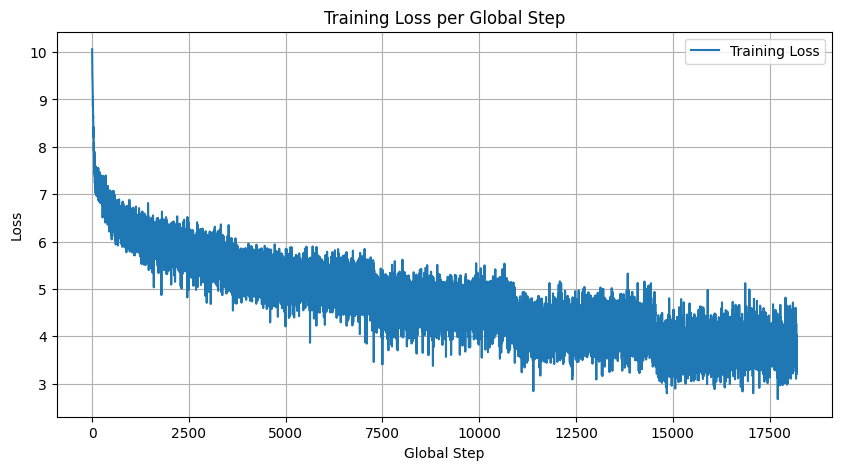

Processing Epoch 05:   1%|          | 23/3638 [00:10<28:38,  2.10it/s, loss=3.064]


KeyboardInterrupt: 

In [28]:
if __name__ == '__main__':
  import os
  from pathlib import Path

  config = get_config()
  train_model(config)


